# Análise Descritiva Profunda: Ecossistema de Comunidades no Reddit

Esta análise detalhada explora a base de dados coletada via API PullPush (Sementes, Depth 0 e Depth 1). 
A abordagem analítica será "Top-Down" (do macro para o micro):
1. **Análise Global:** Período de coleta, volume total, taxas de texto nulo, contagem de palavras e engajamento geral.
2. **Análise por Profundidade (Depth 0 vs 1):** Como o comportamento textual e de engajamento muda do núcleo da bolha para a periferia.
3. **Análise por Subreddit:** O perfil específico das principais comunidades da rede.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)

In [ ]:
def carregar_dados_por_depth(base_dir):
    dados = []
    base_path = Path(base_dir)
    for depth in ['0', '1']:
        folder_path = base_path / depth / 'subreddits'
        if folder_path.exists():
            for file_path in folder_path.glob('*.json'):
                with open(file_path, 'r', encoding='utf-8') as f:
                    try:
                        posts = json.load(f)
                        for post in posts:
                            post['depth'] = int(depth)
                            dados.append(post)
                    except json.JSONDecodeError:
                        pass
    return pd.DataFrame(dados)

data_path = "../db2" 
df_raw = carregar_dados_por_depth(data_path)
df = df_raw.copy().drop_duplicates(subset=['id'])
print(f"Total de registros únicos carregados: {len(df)}")

Total de registros únicos carregados: 1383518


In [ ]:
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['num_comments'] = pd.to_numeric(df['num_comments'], errors='coerce')
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)

df['removed_by_category'] = df['removed_by_category'].fillna('Ativo')
df['over_18'] = df['over_18'].astype(bool) # NSFW

df['is_selftext_null'] = df['selftext'].isnull() | (df['selftext'] == '') | (df['selftext'] == '[deleted]') | (df['selftext'] == '[removed]')

def contar_palavras(texto):
    if pd.isna(texto) or texto in ['[deleted]', '[removed]', '']:
        return 0
    return len(str(texto).split())

df['selftext_word_count'] = df['selftext'].apply(contar_palavras)

print("Pré-processamento concluído com sucesso.")

Pré-processamento concluído com sucesso.


## 1. Análise Global do Ecossistema
Visão consolidada de todas as postagens recuperadas, detalhando os níveis de engajamento médio, taxas de conteúdo adulto (+18), volume de postagens sem texto longo (links/imagens) e o panorama de moderação (posts removidos).

In [4]:
print("================ ESTATÍSTICAS GLOBAIS ================\n")

total_posts = len(df)
nulos_selftext = df['is_selftext_null'].sum()
nsfw_posts = df['over_18'].sum()
removidos_posts = len(df[df['removed_by_category'] != 'Ativo'])

print(f"1. VOLUME GERAL")
print(f"Total de Posts: {total_posts:,}")
print(f"Subreddits Únicos: {df['subreddit'].nunique():,}\n")

print(f"2. COMPOSIÇÃO E CONTEÚDO")
print(f"Posts sem corpo de texto (Links/Mídia/Vazios): {nulos_selftext:,} ({(nulos_selftext/total_posts)*100:.2f}%)")
print(f"Posts marcados como +18 (NSFW): {nsfw_posts:,} ({(nsfw_posts/total_posts)*100:.2f}%)")
print(f"Média de Palavras no Texto (quando existe): {df[~df['is_selftext_null']]['selftext_word_count'].mean():.1f} palavras\n")

print(f"3. ENGAJAMENTO (Média / Mediana)")
print(f"Score (Upvotes): {df['score'].mean():.2f} / {df['score'].median()}")
print(f"Comentários: {df['num_comments'].mean():.2f} / {df['num_comments'].median()}\n")

print(f"4. MODERAÇÃO")
print(f"Posts Removidos/Deletados: {removidos_posts:,} ({(removidos_posts/total_posts)*100:.2f}%)")
print("\nDetalhamento do Status (removed_by_category):")
display(df['removed_by_category'].value_counts().to_frame(name='Quantidade'))

================ ESTATÍSTICAS GLOBAIS ================

1. VOLUME GERAL
Total de Posts: 1,383,518
Subreddits Únicos: 4,738

2. COMPOSIÇÃO E CONTEÚDO
Posts sem corpo de texto (Links/Mídia/Vazios): 1,150,143 (83.13%)
Posts marcados como +18 (NSFW): 74,810 (5.41%)
Média de Palavras no Texto (quando existe): 204.3 palavras

3. ENGAJAMENTO (Média / Mediana)
Score (Upvotes): 6230.91 / 1340.0
Comentários: 261.26 / 72.0

4. MODERAÇÃO
Posts Removidos/Deletados: 112,468 (8.13%)

Detalhamento do Status (removed_by_category):


,Quantidade
removed_by_category,
Ativo,1271050
deleted,70768
moderator,31026
reddit,8647
copyright_takedown,695
automod_filtered,677
content_takedown,441
author,106
anti_evil_ops,96


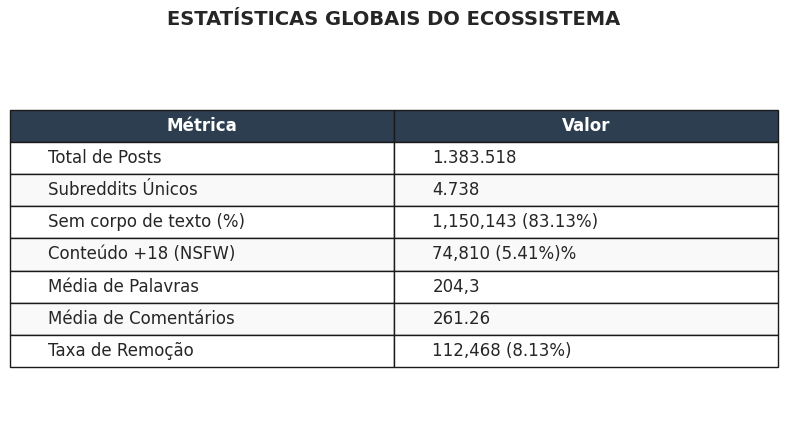

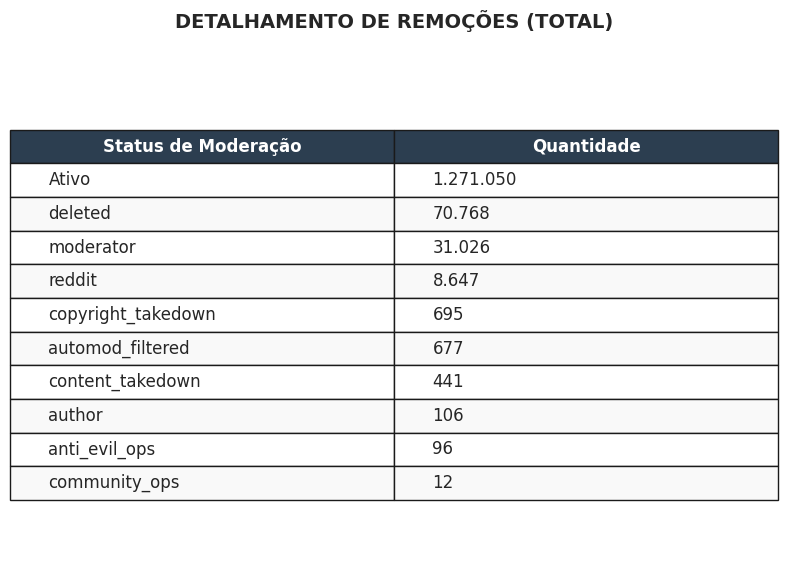

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

dados_resumo = [
    ["Total de Posts", "1.383.518"],
    ["Subreddits Únicos", "4.738"],
    ["Sem corpo de texto (%)", "1,150,143 (83.13%)"],
    ["Conteúdo +18 (NSFW)", "74,810 (5.41%)%"],
    ["Média de Palavras", "204,3"],
    ["Média de Comentários","261.26"],
    ["Taxa de Remoção", "112,468 (8.13%)"]
]

dados_mod = [
    ["Ativo", "1.271.050"],
    ["deleted", "70.768"],
    ["moderator", "31.026"],
    ["reddit", "8.647"],
    ["copyright_takedown", "695"],
    ["automod_filtered", "677"],
    ["content_takedown", "441"],
    ["author", "106"],
    ["anti_evil_ops", "96"],
    ["community_ops", "12"]
]

def renderizar_tabela(dados, colunas, titulo, cor_cabecalho='#2c3e50'):
    fig, ax = plt.subplots(figsize=(8, len(dados) * 0.5 + 1))
    ax.axis('off')
    
    tab = ax.table(cellText=dados, colLabels=colunas, loc='center', cellLoc='left')
    
    tab.auto_set_font_size(False)
    tab.set_fontsize(12)
    tab.scale(1.2, 1.8) 
    
    for (row, col), cell in tab.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor(cor_cabecalho)
        elif row % 2 == 0:
            cell.set_facecolor('#f9f9f9')
            
    plt.title(titulo, fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

renderizar_tabela(dados_resumo, ["Métrica", "Valor"], "ESTATÍSTICAS GLOBAIS DO ECOSSISTEMA")
renderizar_tabela(dados_mod, ["Status de Moderação", "Quantidade"], "DETALHAMENTO DE REMOÇÕES (TOTAL)")


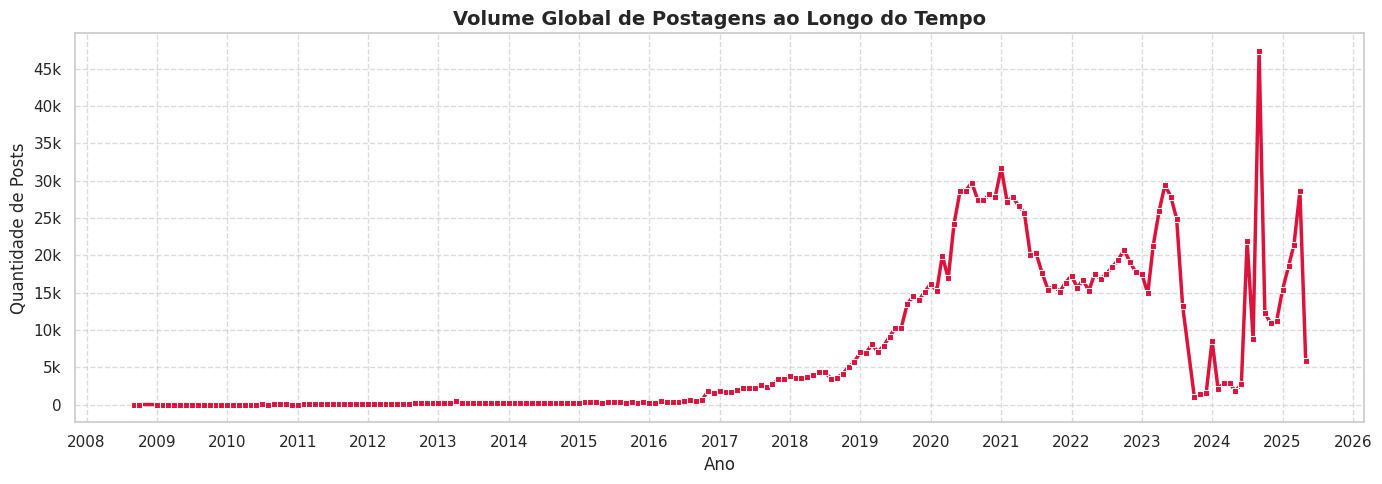

In [ ]:
# ==========================================
# ANÁLISE TEMPORAL
# ==========================================
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

plt.figure(figsize=(14, 5))

df['ano_mes'] = df['timestamp'].dt.to_period('M')

posts_por_mes = df['ano_mes'].dropna().value_counts().sort_index()

posts_por_mes.index = posts_por_mes.index.to_timestamp()

ax = sns.lineplot(x=posts_por_mes.index, y=posts_por_mes.values, color='crimson', linewidth=2.5, marker='s', markersize=5)

ax.xaxis.set_major_locator(mdates.YearLocator()) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) 

ax.yaxis.set_major_locator(ticker.MultipleLocator(5000)) 
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'))

plt.title('Volume Global de Postagens ao Longo do Tempo', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade de Posts')
plt.xlabel('Ano')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

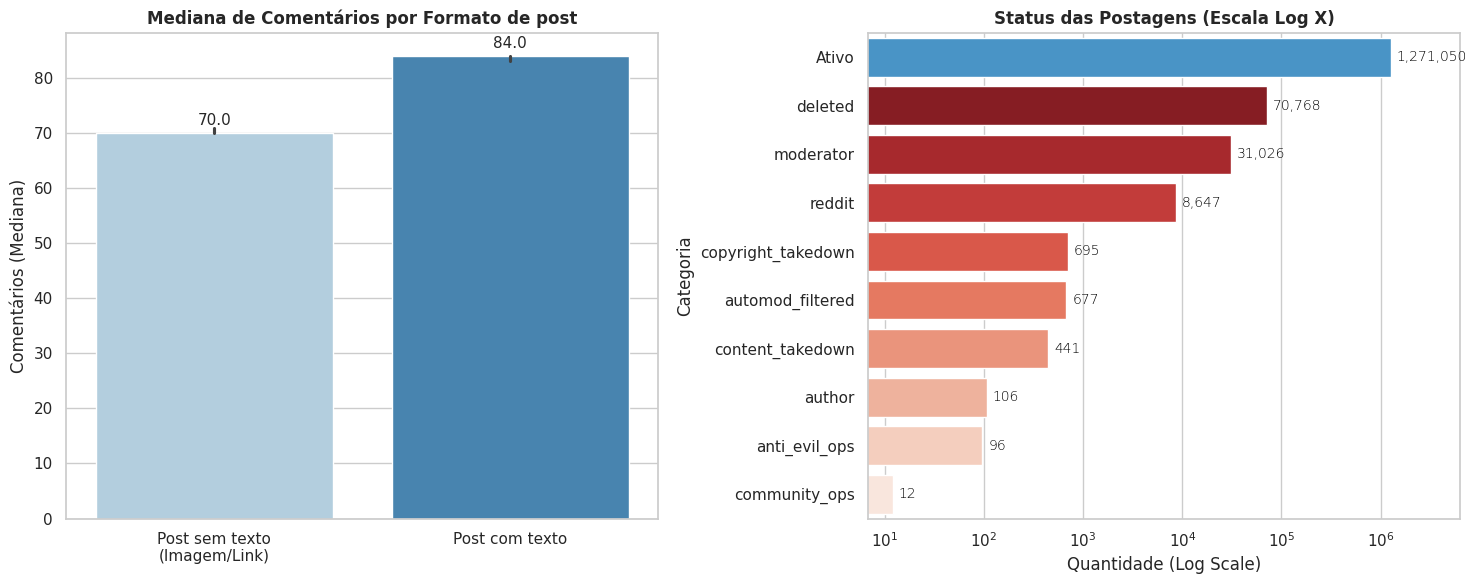

In [ ]:
# ==========================================
# 2. VISUALIZAÇÕES GLOBAIS (Textos, NSFW e Remoções)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) 

df['formato_post'] = np.where(df['is_selftext_null'], 'Post sem texto\n(Imagem/Link)', 'Post com texto')

# Usamos a mediana (estimator=np.median) porque já vimos que a média é distorcida
sns.barplot(data=df, x='formato_post', y='num_comments', ax=axes[0], palette='Blues', estimator=np.median)

axes[0].set_title('Mediana de Comentários por Formato de post', fontweight='bold')
axes[0].set_ylabel('Comentários (Mediana)')
axes[0].set_xlabel('')

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', 
                     xytext=(0, 9), 
                     textcoords='offset points',
                     fontsize=11)
    
ordem_remocao = df['removed_by_category'].value_counts().index
valores_remocao = df['removed_by_category'].value_counts().values

paleta_customizada = []
tons_vermelho = sns.color_palette("Reds_r", n_colors=len(ordem_remocao) - 1)
idx_vermelho = 0

for cat in ordem_remocao:
    if cat == 'Ativo':
        paleta_customizada.append('#3498db') # Azul
    else:
        paleta_customizada.append(tons_vermelho[idx_vermelho])
        idx_vermelho += 1

barplot = sns.countplot(data=df, y='removed_by_category', ax=axes[1], palette=paleta_customizada, order=ordem_remocao)

axes[1].set_title('Status das Postagens (Escala Log X)', fontweight='bold')
axes[1].set_ylabel('Categoria')
axes[1].set_xlabel('Quantidade (Log Scale)')
axes[1].set_xscale('log')

for p, valor in zip(axes[1].patches, valores_remocao):
    axes[1].annotate(f'{valor:,}', 
                     (valor + (valor * 0.15), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', 
                     fontsize=10, color='black',
                     fontweight='light')

axes[1].set_xlim(right=valores_remocao.max() * 5) 

plt.tight_layout()
plt.show()

## Dicionário de Dados: Categorias de Remoção (`removed_by_category`)

Na API do Reddit (via PullPush/Pushshift), o campo `removed_by_category` indica o status atual da postagem e **quem** foi o responsável por retirá-la do ar, caso ela não esteja mais visível. 

Compreender essas categorias é vital para medir o nível de toxicidade de uma comunidade e se ela possui auto-regulação ou exige intervenção externa.

### 1. Status Regular
* **Ativo:** A postagem está no ar, pública e visível. *(Nota: A API retorna nulo para estes casos, mas imputamos como "Ativo" no pré-processamento para fins analíticos).*

### 2. Ações do Próprio Usuário
* **deleted:** O próprio autor optou por excluir a postagem. O conteúdo textual é apagado e o nome do usuário é ocultado da interface.
* **author:** Funcionalmente idêntico ao `deleted`. Indica um evento de deleção originado diretamente pelo cliente (o autor), dependendo do momento e método de extração da API.

### 3. Moderação Local (Auto-regulação da Bolha)
* **moderator:** Remoção feita por um moderador humano do próprio subreddit. Indica que o post violou regras internas da comunidade (ex: fuga do tema, quebra de formatação, ou regras específicas do sub).
* **automod_filtered:** Remoção automática feita pelo bot *AutoModerator*. Os moderadores locais configuram este bot com regras (RegEx) para barrar instantaneamente posts com palavras proibidas, links de spam ou autores com contas muito novas/karma baixo.

### 4. Intervenção Global (Administração do Reddit)
* **reddit:** Remoção genérica pelo sistema de administração centralizada do Reddit, geralmente por violação ampla dos Termos de Serviço (ToS), como spam massivo, manipulação de votos ou evasão de banimento.
* **anti_evil_ops:** Remoção crítica feita pelo esquadrão de **Anti-Evil Operations (AEO)** do Reddit. Esta equipe lida com violações severas e tóxicas, como discurso de ódio explícito, assédio direcionado, *doxing* (exposição de dados pessoais) e ameaças de violência.
* **community_ops:** Remoção pela equipe de *Community Operations*. Eles atuam em problemas sistêmicos, disputas entre subreddits (brigadas) ou quando os moderadores locais perdem o controle da própria comunidade.
* **copyright_takedown:** Remoção legal via DMCA (Direitos Autorais). O Reddit foi notificado e legalmente obrigado a derrubar o conteúdo (comum com links piratas ou mídia vazada protegida).
* **content_takedown:** Remoção administrativa atrelada a quebras extremas das políticas de segurança, envolvendo materiais ilegais, imagens íntimas não consensuais ou conteúdos que ferem legislações internacionais graves.

## 2. Análise Estratificada: Depth 0 vs Depth 1
Comparação direta entre o comportamento das "Sementes" (a bolha original) e o "Transbordamento" (as comunidades descobertas pelos autores). 
Avaliaremos se os autores transacionam para comunidades com regras diferentes de moderação, formatos diferentes (mais mídia vs texto) ou temáticas mais adultas.

In [ ]:
print("================ COMPARAÇÃO: DEPTH 0 vs DEPTH 1 ================\n")

agg_depth = df.groupby('depth').agg(
    Volume_Posts=('id', 'count'),
    Sem_Texto_Pct=('is_selftext_null', lambda x: (x.mean() * 100).round(2)),
    NSFW_Pct=('over_18', lambda x: (x.mean() * 100).round(2)),
    Removidos_Pct=('removed_by_category', lambda x: ((x != 'Ativo').mean() * 100).round(2)),
    Media_Score=('score', lambda x: x.mean().round(2)),
    Mediana_Score=('score', 'median'),
    Media_Comments=('num_comments', lambda x: x.mean().round(2)),
    Mediana_Comments=('num_comments', 'median')
).T 

display(agg_depth)

print("\n=== Detalhamento da Moderação por Depth (Qtd Absoluta) ===")
mod_crosstab = pd.crosstab(df['removed_by_category'], df['depth'], margins=True, margins_name="Total")
display(mod_crosstab.sort_values(by='Total', ascending=False))

================ COMPARAÇÃO: DEPTH 0 vs DEPTH 1 ================



depth,0,1
Volume_Posts,148159.00,1235359.00
Sem_Texto_Pct,71.88,84.48
NSFW_Pct,2.71,5.73
Removidos_Pct,12.00,7.67
Media_Score,14823.51,5200.38
Mediana_Score,2312.00,1271.00
Media_Comments,777.37,199.36
Mediana_Comments,222.00,64.00



=== Detalhamento da Moderação por Depth (Qtd Absoluta) ===


depth,0,1,Total
removed_by_category,,,
Total,148159,1235359,1383518
Ativo,130384,1140666,1271050
deleted,12662,58106,70768
moderator,3990,27036,31026
reddit,861,7786,8647
copyright_takedown,41,654,695
automod_filtered,87,590,677
content_takedown,106,335,441
author,14,92,106


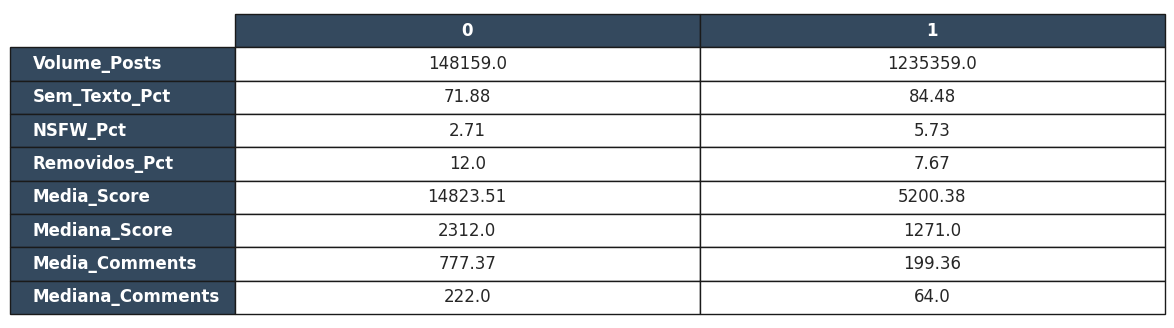

In [ ]:
import matplotlib.pyplot as plt

def salvar_tabela_como_imagem(df_styled, nome_arquivo="tabela_slide.png"):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis('off')
    
    tabela = ax.table(cellText=df_styled.values, 
                      colLabels=df_styled.columns, 
                      rowLabels=df_styled.index,
                      loc='center', 
                      cellLoc='center')
    
    tabela.auto_set_font_size(False)
    tabela.set_fontsize(12)
    tabela.scale(1.2, 2) 
    
    for (row, col), cell in tabela.get_celld().items():
        if row == 0 or col == -1:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#34495e') # Azul escuro profissional
            
    plt.savefig(nome_arquivo, bbox_inches='tight', dpi=300)
    plt.show()

tabela_limpa = agg_depth.round(2)
salvar_tabela_como_imagem(tabela_limpa)

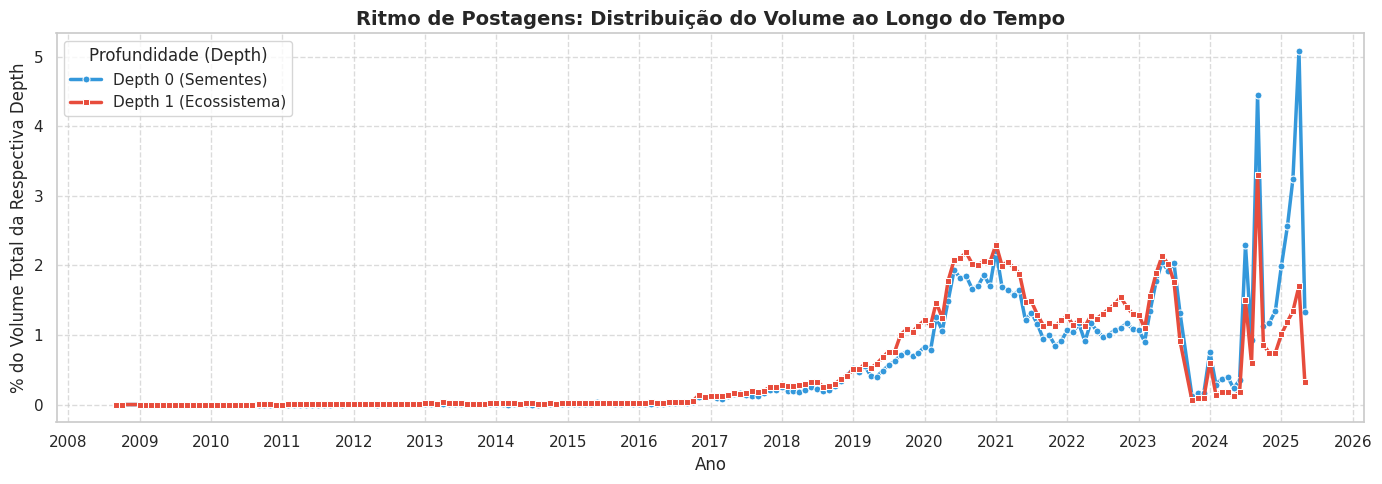

<Figure size 1400x600 with 0 Axes>

In [ ]:
# ==========================================
#  VISUALIZAÇÕES: DEPTH 0 vs DEPTH 1
# ==========================================

import matplotlib.dates as mdates 

plt.figure(figsize=(14, 5))

temporal_depth = df.groupby(['ano_mes', 'depth']).size().unstack(fill_value=0)

temporal_pct = temporal_depth.div(temporal_depth.sum(axis=0), axis=1) * 100

temporal_pct.index = temporal_pct.index.to_timestamp()

ax = sns.lineplot(data=temporal_pct[0], label='Depth 0 (Sementes)', color='#3498db', linewidth=2.5, marker='o', markersize=5)
sns.lineplot(data=temporal_pct[1], label='Depth 1 (Ecossistema)', color='#e74c3c', linewidth=2.5, marker='s', markersize=5, ax=ax)

ax.xaxis.set_major_locator(mdates.YearLocator()) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) 

plt.title('Ritmo de Postagens: Distribuição do Volume ao Longo do Tempo', fontsize=14, fontweight='bold')
plt.ylabel('% do Volume Total da Respectiva Depth')
plt.xlabel('Ano')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Profundidade (Depth)')
plt.tight_layout()
plt.show()


plt.tight_layout()
plt.show()

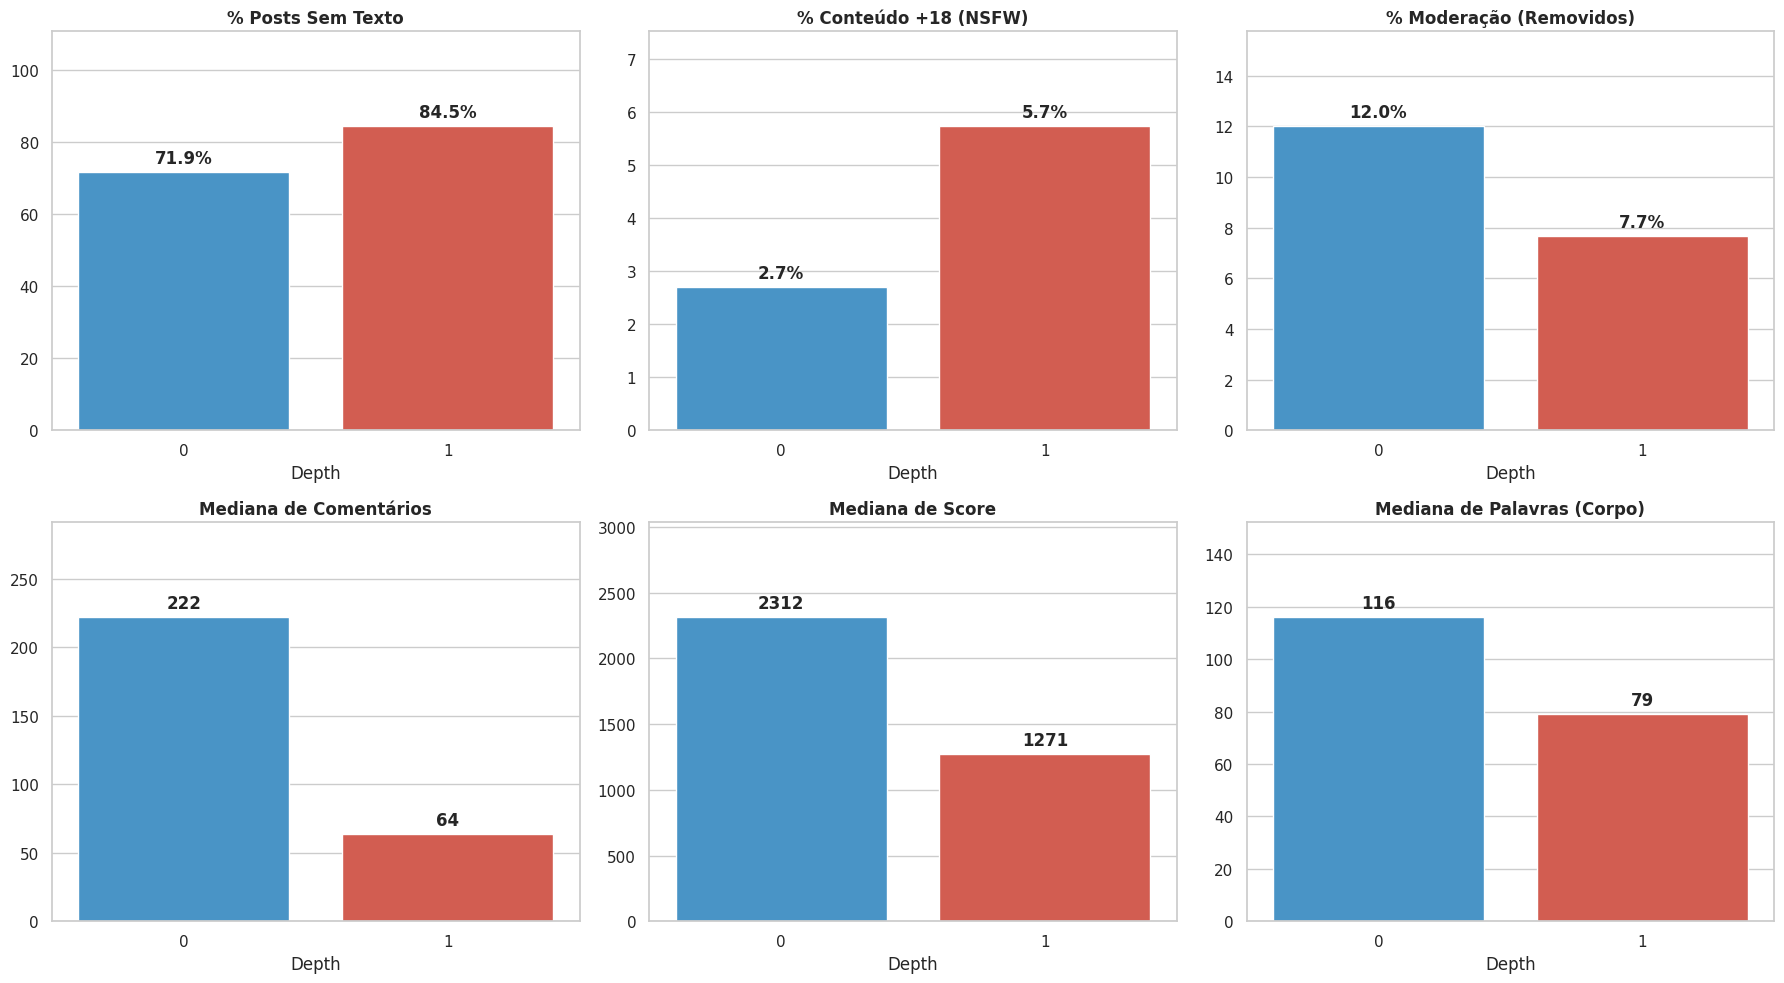

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10)) 

cores_depth = ['#3498db', '#e74c3c'] 

plot_data = df.groupby('depth').agg(
    pct_sem_texto=('is_selftext_null', lambda x: x.mean() * 100),
    pct_nsfw=('over_18', lambda x: x.mean() * 100),
    pct_removidos=('removed_by_category', lambda x: (x != 'Ativo').mean() * 100),
    mediana_comentarios=('num_comments', 'median'),
    mediana_score=('score', 'median'),
    # Mediana de palavras apenas para quem TEM texto
    mediana_palavras=('selftext_word_count', lambda x: x[x > 0].median())
).reset_index()

def adicionar_labels(ax, is_percent=True):
    for p in ax.patches:
        valor = p.get_height()
        texto = f'{valor:.1f}%' if is_percent else f'{int(valor)}'
        ax.annotate(texto, 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=12, fontweight='bold')

sns.barplot(data=plot_data, x='depth', y='pct_sem_texto', ax=axes[0, 0], palette=cores_depth)
axes[0, 0].set_title('% Posts Sem Texto', fontweight='bold')
adicionar_labels(axes[0, 0])

sns.barplot(data=plot_data, x='depth', y='pct_nsfw', ax=axes[0, 1], palette=cores_depth)
axes[0, 1].set_title('% Conteúdo +18 (NSFW)', fontweight='bold')
adicionar_labels(axes[0, 1])

sns.barplot(data=plot_data, x='depth', y='pct_removidos', ax=axes[0, 2], palette=cores_depth)
axes[0, 2].set_title('% Moderação (Removidos)', fontweight='bold')
adicionar_labels(axes[0, 2])

sns.barplot(data=plot_data, x='depth', y='mediana_comentarios', ax=axes[1, 0], palette=cores_depth)
axes[1, 0].set_title('Mediana de Comentários', fontweight='bold')
adicionar_labels(axes[1, 0], is_percent=False)

sns.barplot(data=plot_data, x='depth', y='mediana_score', ax=axes[1, 1], palette=cores_depth)
axes[1, 1].set_title('Mediana de Score', fontweight='bold')
adicionar_labels(axes[1, 1], is_percent=False)

sns.barplot(data=plot_data, x='depth', y='mediana_palavras', ax=axes[1, 2], palette=cores_depth)
axes[1, 2].set_title('Mediana de Palavras (Corpo)', fontweight='bold')
adicionar_labels(axes[1, 2], is_percent=False)

for row in axes:
    for ax in row:
        ax.set_ylim(top=ax.get_ylim()[1] * 1.25)
        ax.set_ylabel('')
        ax.set_xlabel('Depth')

plt.tight_layout()
plt.show()